# 🚲 Dublin Bikes Availability Prediction Model

## Project Objective
Train a machine learning model using historical bike and weather data  
to predict the **number of available bikes** at a station for a specific time.

## Dataset
- File name: `final_merged_data.csv`
- Content: merged bike station history data + weather data

## Notebook Structure
1. Environment setup & data loading
2. Data exploration (EDA)
3. Data cleaning & preprocessing
4. Feature engineering
5. Model training & comparison
6. Model evaluation
7. Save the best model

In [1]:
# Data processing
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager

# Machine learning
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Model persistence
import pickle
import joblib

# Other
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Chinese font configuration
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# Set pandas display options
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


## 1. Data Loading

Read `final_merged_data.csv` and perform an initial inspection:
- Number of rows and columns
- Preview of the first few rows
- Column names and data types
- Basic statistics

In [2]:
# Load data
df = pd.read_csv('final_merged_data.csv')

# Basic information
print(f"📊 Dataset size: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"\n📋 Column name list:")
print(df.columns.tolist())
print(f"\n🔍 Data types:")
print(df.dtypes)

📊 Dataset size: 298946 rows x 78 columns

📋 Column name list:
['last_reported', 'station_id', 'num_bikes_available', 'num_docks_available', 'is_installed', 'is_renting', 'is_returning', 'name', 'address', 'lat', 'lon', 'capacity', 'stno', 'year', 'month', 'day', 'hour', 'minute', 'max_air_temp_quality_indicator', 'max_air_temperature_celsius', 'min_air_temp_quality_indicator', 'min_air_temperature_celsius', 'air_temp_std_quality_indicator', 'air_temperature_std_deviation', 'max_grass_temp_quality_indicator', 'max_grass_temperature_celsius', 'min_grass_temp_quality_indicator', 'min_grass_temperature_celsius', 'grass_temp_std_quality_indicator', 'grass_temperature_std_deviation', 'max_soil_temp_5cm_quality_indicator', 'max_soil_temperature_5cm_celsius', 'min_soil_temp_5cm_quality_indicator', 'min_soil_temperature_5cm_celsius', 'soil_temp_std_5cm_quality_indicator', 'soil_temperature_std_deviation_5cm', 'max_soil_temp_10cm_quality_indicator', 'max_soil_temperature_10cm_celsius', 'min_soil

## 2. Initial Data Exploration (EDA)

First, inspect the basic status of the data:
- Missing value distribution
- Target variable distribution
- Preview the first few rows

In [3]:
# Preview first 5 rows
print("📋 Preview of first 5 rows:")
df.head()

📋 Preview of first 5 rows:


,last_reported,station_id,num_bikes_available,num_docks_available,is_installed,is_renting,is_returning,name,address,lat,lon,capacity,stno,year,month,day,hour,minute,max_air_temp_quality_indicator,max_air_temperature_celsius,min_air_temp_quality_indicator,min_air_temperature_celsius,air_temp_std_quality_indicator,air_temperature_std_deviation,max_grass_temp_quality_indicator,max_grass_temperature_celsius,min_grass_temp_quality_indicator,min_grass_temperature_celsius,grass_temp_std_quality_indicator,grass_temperature_std_deviation,max_soil_temp_5cm_quality_indicator,max_soil_temperature_5cm_celsius,min_soil_temp_5cm_quality_indicator,min_soil_temperature_5cm_celsius,soil_temp_std_5cm_quality_indicator,soil_temperature_std_deviation_5cm,max_soil_temp_10cm_quality_indicator,max_soil_temperature_10cm_celsius,min_soil_temp_10cm_quality_indicator,min_soil_temperature_10cm_celsius,soil_temp_std_10cm_quality_indicator,soil_temperature_std_deviation_10cm,max_soil_temp_20cm_quality_indicator,max_soil_temperature_20cm_celsius,min_soil_temp_20cm_quality_indicator,min_soil_temperature_20cm_celsius,soil_temp_std_20cm_quality_indicator,soil_temperature_std_deviation_20cm,max_earth_temp_30cm_quality_indicator,max_earth_temperature_30cm_celsius,min_earth_temp_30cm_quality_indicator,min_earth_temperature_30cm_celsius,earth_temp_std_30cm_quality_indicator,earth_temperature_std_deviation_30cm,max_earth_temp_50cm_quality_indicator,max_earth_temperature_50cm_celsius,min_earth_temp_50cm_quality_indicator,min_earth_temperature_50cm_celsius,earth_temp_std_50cm_quality_indicator,earth_temperature_std_deviation_50cm,max_earth_temp_100cm_quality_indicator,max_earth_temperature_100cm_celsius,min_earth_temp_100cm_quality_indicator,min_earth_temperature_100cm_celsius,earth_temp_std_100cm_quality_indicator,earth_temperature_std_deviation_100cm,max_humidity_quality_indicator,max_relative_humidity_percent,min_humidity_quality_indicator,min_relative_humidity_percent,humidity_std_quality_indicator,relative_humidity_std_deviation,max_pressure_quality_indicator,max_barometric_pressure_hpa,min_pressure_quality_indicator,min_barometric_pressure_hpa,pressure_std_quality_indicator,barometric_pressure_std_deviation
0,2024-12-01 00:10:00,10,15,1,True,True,True,DAME STREET,Dame Street,53.344,-6.267,16,175,2024,12,1,0,10,0,14.010,0,13.900,0,0.033,0,11.930,0,11.730,0,0.056,0,10.150,0,10.110,0,0.008,0,9.580,0,9.560,0,0.005,0,8.830,0,8.800,0,0.007,0,8.880,0,8.850,0,0.008,0,8.500,0,8.470,0,0.008,0,9.870,0,9.830,0,0.008,0,84.300,0,83.200,0,0.284,0,1002.560,0,1002.260,0,0.083
1,2024-12-01 00:10:00,100,17,8,True,True,True,HEUSTON BRIDGE (SOUTH),Heuston Bridge (South),53.347,-6.292,25,175,2024,12,1,0,10,0,14.010,0,13.900,0,0.033,0,11.930,0,11.730,0,0.056,0,10.150,0,10.110,0,0.008,0,9.580,0,9.560,0,0.005,0,8.830,0,8.800,0,0.007,0,8.880,0,8.850,0,0.008,0,8.500,0,8.470,0,0.008,0,9.870,0,9.830,0,0.008,0,84.300,0,83.200,0,0.284,0,1002.560,0,1002.260,0,0.083
2,2024-12-01 00:10:00,109,20,9,True,True,True,BUCKINGHAM STREET LOWER,Buckingham Street Lower,53.353,-6.249,29,175,2024,12,1,0,10,0,14.010,0,13.900,0,0.033,0,11.930,0,11.730,0,0.056,0,10.150,0,10.110,0,0.008,0,9.580,0,9.560,0,0.005,0,8.830,0,8.800,0,0.007,0,8.880,0,8.850,0,0.008,0,8.500,0,8.470,0,0.008,0,9.870,0,9.830,0,0.008,0,84.300,0,83.200,0,0.284,0,1002.560,0,1002.260,0,0.083
3,2024-12-01 00:10:00,11,1,29,True,True,True,EARLSFORT TERRACE,Earlsfort Terrace,53.334,-6.259,30,175,2024,12,1,0,10,0,14.010,0,13.900,0,0.033,0,11.930,0,11.730,0,0.056,0,10.150,0,10.110,0,0.008,0,9.580,0,9.560,0,0.005,0,8.830,0,8.800,0,0.007,0,8.880,0,8.850,0,0.008,0,8.500,0,8.470,0,0.008,0,9.870,0,9.830,0,0.008,0,84.300,0,83.200,0,0.284,0,1002.560,0,1002.260,0,0.083
4,2024-12-01 00:10:00,114,4,36,True,True,True,WILTON TERRACE (PARK),Wilton Terrace (Park),53.334,-6.248,40,175,2024,12,1,0,10,0,14.010,0,13.900,0,0.033,0,11.930,0,11.730,0,0.056,0,10.150,0,10.110,0,0.008,0,9.580,0,9.560,0,0.005,0,8.830,0,8.800,0,0.007,0,8.880,0,8.850,0,0.008,0,8.500,0,8.470,0

In [4]:
# Missing value summary
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Ratio (%)': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing Ratio (%)', ascending=False)

print(f"⚠️  Total {len(missing_df)} columns with missing values:\n")
print(missing_df)

⚠️  Total 0 columns with missing values:

Empty DataFrame
Columns: [Missing Count, Missing Ratio (%)]
Index: []


📊 Target variable num_bikes_available statistics:
count   298946.000
mean        12.205
std          9.762
min          0.000
25%          4.000
50%         11.000
75%         19.000
max         40.000
Name: num_bikes_available, dtype: float64


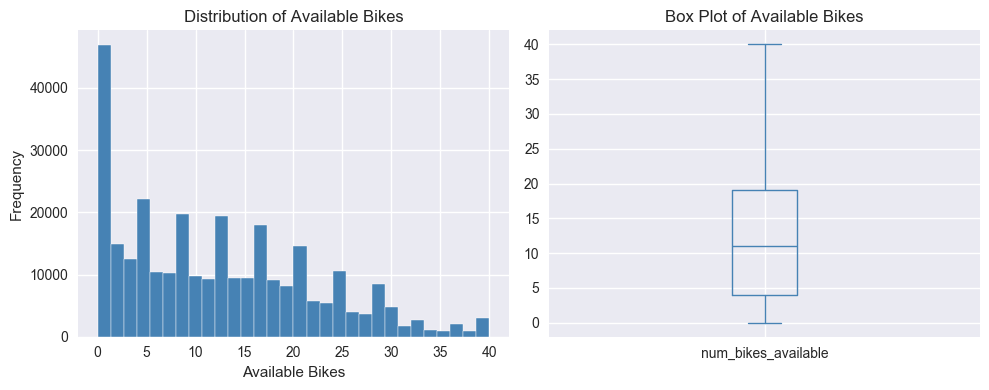

In [5]:
# Target variable distribution
print("📊 Target variable num_bikes_available statistics:")
print(df['num_bikes_available'].describe())

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
df['num_bikes_available'].hist(bins=30, color='steelblue', edgecolor='white')
plt.title('Distribution of Available Bikes')
plt.xlabel('Available Bikes')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
df['num_bikes_available'].plot(kind='box', color='steelblue')
plt.title('Box Plot of Available Bikes')

plt.tight_layout()
plt.show()

## 3. Feature Selection

Based on column analysis, keep the following meaningful features:

**Time features:** `hour`, `month`, `day`, `year`

**Station features:** `station_id`, `capacity`, `lat`, `lon`

**Weather features:**
- Temperature:`max_air_temperature_celsius`, `min_air_temperature_celsius`
- Humidity:`max_relative_humidity_percent`, `min_relative_humidity_percent`
- Pressure:`max_barometric_pressure_hpa`, `min_barometric_pressure_hpa`

**Reasons for removal:**
- All `quality_indicator` columns -> quality flags, not actual numeric values
- All `std_deviation` columns -> redundant information
- Soil/grass temperatures → low relevance to bike usage
- `name`, `address`, `last_reported` → text columns, not used for modeling
- `is_installed`, `is_renting`, `is_returning` → almost always True, low discriminative power

**Target variable:** `num_bikes_available`

In [6]:
# Select required columns
selected_columns = [
    # Time features
    'hour', 'month', 'day', 'year',
    
    # Station features
    'station_id', 'capacity', 'lat', 'lon',
    
    # Weather features
    'max_air_temperature_celsius', 'min_air_temperature_celsius',
    'max_relative_humidity_percent', 'min_relative_humidity_percent',
    'max_barometric_pressure_hpa', 'min_barometric_pressure_hpa',
    
    # Target variable
    'num_bikes_available'
]

# Create a new DataFrame
df_model = df[selected_columns].copy()

print(f"✅ Feature selection completed")
print(f"📊 New dataset size: {df_model.shape[0]} rows x {df_model.shape[1]} columns")
print(f"\n📋 Data types of each column:")
print(df_model.dtypes)
print(f"\n📋 First 5 rows preview:")
df_model.head()

✅ Feature selection completed
📊 New dataset size: 298946 rows x 15 columns

📋 Data types of each column:
hour                               int64
month                              int64
day                                int64
year                               int64
station_id                         int64
capacity                           int64
lat                              float64
lon                              float64
max_air_temperature_celsius      float64
min_air_temperature_celsius      float64
max_relative_humidity_percent    float64
min_relative_humidity_percent    float64
max_barometric_pressure_hpa      float64
min_barometric_pressure_hpa      float64
num_bikes_available                int64
dtype: object

📋 First 5 rows preview:


,hour,month,day,year,station_id,capacity,lat,lon,max_air_temperature_celsius,min_air_temperature_celsius,max_relative_humidity_percent,min_relative_humidity_percent,max_barometric_pressure_hpa,min_barometric_pressure_hpa,num_bikes_available
0,0,12,1,2024,10,16,53.344,-6.267,14.010,13.900,84.300,83.200,1002.560,1002.260,15
1,0,12,1,2024,100,25,53.347,-6.292,14.010,13.900,84.300,83.200,1002.560,1002.260,17
2,0,12,1,2024,109,29,53.353,-6.249,14.010,13.900,84.300,83.200,1002.560,1002.260,20
3,0,12,1,2024,11,30,53.334,-6.259,14.010,13.900,84.300,83.200,1002.560,1002.260,1
4,0,12,1,2024,114,40,53.334,-6.248,14.010,13.900,84.300,83.200,1002.560,1002.260,4


## 4. Feature engineering

Based on existing features, add the following derived features:

- `day_of_week`: day of week (0=Monday, 6=Sunday), captures weekday/weekend patterns
- `is_weekend`: whether it is weekend (0 or 1), a direct weekend flag
- `avg_temperature`: average of max and min temperature as representative temperature
- `avg_humidity`: average of max and min humidity
- `avg_pressure`: average of max and min pressure

In [7]:
# Add derived features
# Build datetime from year/month/day to extract day of week
df_model['day_of_week'] = pd.to_datetime(df[['year', 'month', 'day']]).dt.dayofweek

# Weekend flag
df_model['is_weekend'] = df_model['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# Average temperature
df_model['avg_temperature'] = (df_model['max_air_temperature_celsius'] + df_model['min_air_temperature_celsius']) / 2

# Average humidity
df_model['avg_humidity'] = (df_model['max_relative_humidity_percent'] + df_model['min_relative_humidity_percent']) / 2

# Average pressure
df_model['avg_pressure'] = (df_model['max_barometric_pressure_hpa'] + df_model['min_barometric_pressure_hpa']) / 2

print(f"✅ Feature engineering completed")
print(f"📊 New dataset size: {df_model.shape[0]} rows x {df_model.shape[1]} columns")
print(f"\nSummary statistics of new features:")
print(df_model[['day_of_week', 'is_weekend', 'avg_temperature', 'avg_humidity', 'avg_pressure']].describe())

✅ Feature engineering completed
📊 New dataset size: 298946 rows x 20 columns

Summary statistics of new features:
       day_of_week  is_weekend  avg_temperature  avg_humidity  avg_pressure
count   298946.000  298946.000       298946.000    298946.000    298946.000
mean         2.923       0.282            7.786        84.285      1014.773
std          2.061       0.450            3.129         8.005        11.859
min          0.000       0.000           -3.484        55.070       975.035
25%          1.000       0.000            5.676        79.770      1005.915
50%          3.000       0.000            7.872        85.350      1017.125
75%          5.000       1.000           10.125        89.600      1022.615
max          6.000       1.000           14.630        98.850      1035.775


## 5. Correlation Analysis

Examine correlations between each feature and the target variable `num_bikes_available`
to identify which features are most helpful for prediction.

📊 Correlation of each feature with num_bikes_available:
capacity                         0.205
lon                              0.125
day_of_week                      0.010
min_relative_humidity_percent    0.009
avg_humidity                     0.009
max_relative_humidity_percent    0.009
is_weekend                       0.007
day                              0.004
max_air_temperature_celsius      0.002
avg_temperature                  0.002
min_air_temperature_celsius      0.002
station_id                      -0.001
max_barometric_pressure_hpa     -0.002
avg_pressure                    -0.002
min_barometric_pressure_hpa     -0.002
hour                            -0.005
lat                             -0.138
month                              NaN
year                               NaN
Name: num_bikes_available, dtype: float64


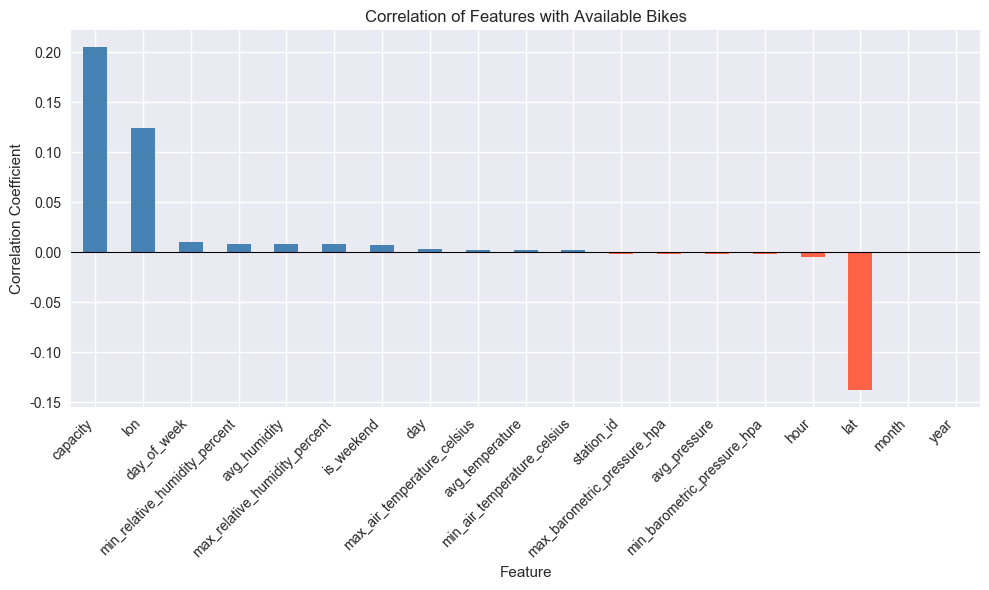

In [8]:
# Compute correlation matrix
corr_matrix = df_model.corr()

# Extract and sort correlations with target variable
target_corr = corr_matrix['num_bikes_available'].drop('num_bikes_available').sort_values(ascending=False)

print("📊 Correlation of each feature with num_bikes_available:")
print(target_corr)

# Visualization
plt.figure(figsize=(10, 6))
colors = ['steelblue' if x > 0 else 'tomato' for x in target_corr.values]
target_corr.plot(kind='bar', color=colors)
plt.title('Correlation of Features with Available Bikes')
plt.xlabel('Feature')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [9]:
# Check unique values of month and year
print("month unique values:", df_model['month'].unique())
print("year unique values:", df_model['year'].unique())

# If either column has a single value, variance is 0 and correlation cannot be computed
print("\nmonth variance:", df_model['month'].var())
print("year variance:", df_model['year'].var())

month unique values: [12]
year unique values: [2024]

month variance: 0.0
year variance: 0.0


In [10]:
# Drop zero-variance columns (not useful for prediction)
df_model = df_model.drop(columns=['month', 'year'])

print(f"✅ Removed month and year columns")
print(f"📊 Current dataset size: {df_model.shape[0]} rows x {df_model.shape[1]} columns")
print(f"\n📋 Current feature list：")
print(df_model.columns.tolist())

✅ Removed month and year columns
📊 Current dataset size: 298946 rows x 18 columns

📋 Current feature list：
['hour', 'day', 'station_id', 'capacity', 'lat', 'lon', 'max_air_temperature_celsius', 'min_air_temperature_celsius', 'max_relative_humidity_percent', 'min_relative_humidity_percent', 'max_barometric_pressure_hpa', 'min_barometric_pressure_hpa', 'num_bikes_available', 'day_of_week', 'is_weekend', 'avg_temperature', 'avg_humidity', 'avg_pressure']


## 6. Define the Final Feature Set

Based on the correlation analysis, define the final features used for training:

**Final feature list:**
- Station features:`station_id`, `capacity`, `lat`, `lon`
- TimeFeature：`hour`, `day`, `day_of_week`, `is_weekend`
- Weather features:`avg_temperature`, `avg_humidity`, `avg_pressure`

**Notes:**
- Remove original weather columns (`max/min`) and keep average versions to reduce redundancy
- Keep all station and time features
- Target variable: `num_bikes_available`

In [11]:
# Define features and target variable
features = [
    'station_id', 'capacity', 'lat', 'lon',
    'hour', 'day', 'day_of_week', 'is_weekend',
    'avg_temperature', 'avg_humidity', 'avg_pressure'
]

target = 'num_bikes_available'

X = df_model[features]
y = df_model[target]

# Split into train and test sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"✅ Dataset split completed")
print(f"📊 Training set size: {X_train.shape[0]} rows")
print(f"📊 Test set size: {X_test.shape[0]} rows")
print(f"📋 Number of features: {X_train.shape[1]} ")
print(f"\nFeature list: {features}")

✅ Dataset split completed
📊 Training set size: 209262 rows
📊 Test set size: 89684 rows
📋 Number of features: 11 

Feature list: ['station_id', 'capacity', 'lat', 'lon', 'hour', 'day', 'day_of_week', 'is_weekend', 'avg_temperature', 'avg_humidity', 'avg_pressure']


## 7. Model Training and Comparison

We will train the following four regression models and compare their performance:

| Model | Description |
|------|------|
| Linear Regression | Linear regression as a baseline model |
| Decision Tree | Decision tree, can capture nonlinear relationships |
| Random Forest | Random forest, ensemble learning, usually performs better |
| Gradient Boosting | Gradient boosting, often the strongest traditional ML model |

**Evaluation metrics:**
- `MAE` (Mean Absolute Error): lower is better
- `RMSE` (Root Mean Squared Error): lower is better  
- `R²` (Coefficient of Determination): closer to 1 is better

In [12]:
from sklearn.metrics import mean_squared_error

# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=15, min_samples_leaf=10),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Train and evaluate each model
results = []

for name, model in models.items():
    print(f"⏳ Training {name}...")
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Evaluate
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4),
        'R²': round(r2, 4)
    })
    
    print(f"   ✅ MAE: {mae:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f}")

# Summarize results
results_df = pd.DataFrame(results).set_index('Model')
print(f"\n📊 Model comparison summary:")
print(results_df)

⏳ Training Linear Regression...
   ✅ MAE: 7.8289 | RMSE: 9.3659 | R²: 0.0746
⏳ Training Decision Tree...
   ✅ MAE: 0.9700 | RMSE: 2.3755 | R²: 0.9405
⏳ Training Random Forest...
   ✅ MAE: 2.3249 | RMSE: 3.3927 | R²: 0.8786
⏳ Training Gradient Boosting...
   ✅ MAE: 6.1196 | RMSE: 7.5375 | R²: 0.4007

📊 Model comparison summary:
                    MAE  RMSE    R²
Model                              
Linear Regression 7.829 9.366 0.075
Decision Tree     0.970 2.376 0.941
Random Forest     2.325 3.393 0.879
Gradient Boosting 6.120 7.537 0.401


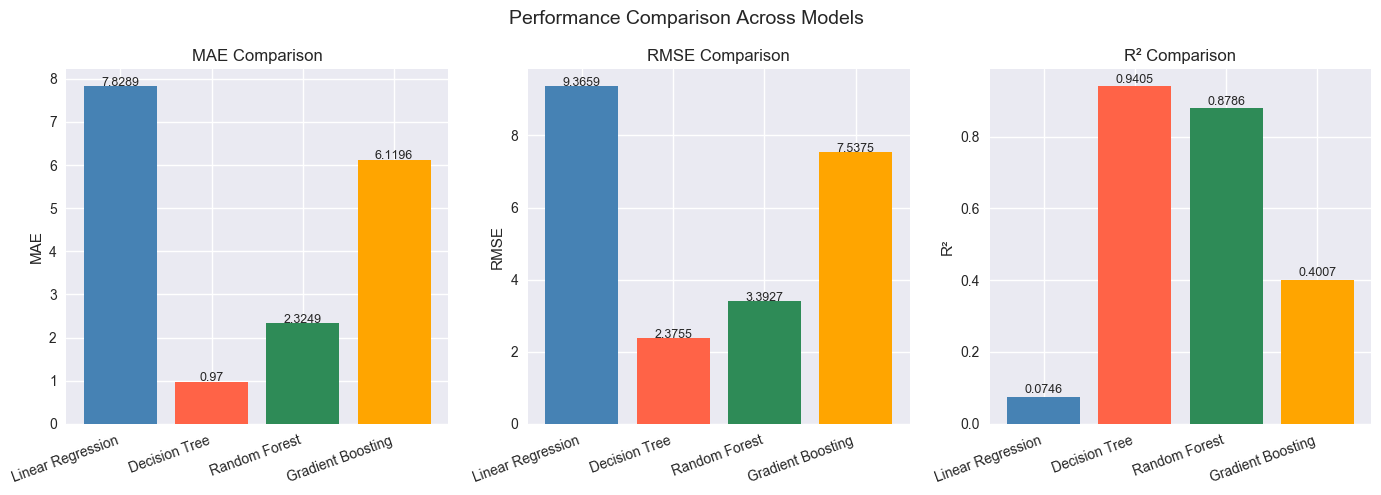

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = ['MAE', 'RMSE', 'R²']
colors = ['steelblue', 'tomato', 'seagreen', 'orange']

for i, metric in enumerate(metrics):
    axes[i].bar(results_df.index, results_df[metric], color=colors)
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_ylabel(metric)
    axes[i].set_xticklabels(results_df.index, rotation=20, ha='right')
    
    # Display values above bars
    for j, v in enumerate(results_df[metric]):
        axes[i].text(j, v + 0.01, str(v), ha='center', fontsize=9)

plt.suptitle('Performance Comparison Across Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Feature Importance Analysis

Use the best model (Decision Tree) to inspect feature importance,
and understand which features contribute most to prediction.

📊 Feature importance ranking:
lat               0.208
day               0.134
lon               0.132
hour              0.107
avg_pressure      0.100
station_id        0.090
capacity          0.068
day_of_week       0.057
avg_temperature   0.051
avg_humidity      0.038
is_weekend        0.014
dtype: float64


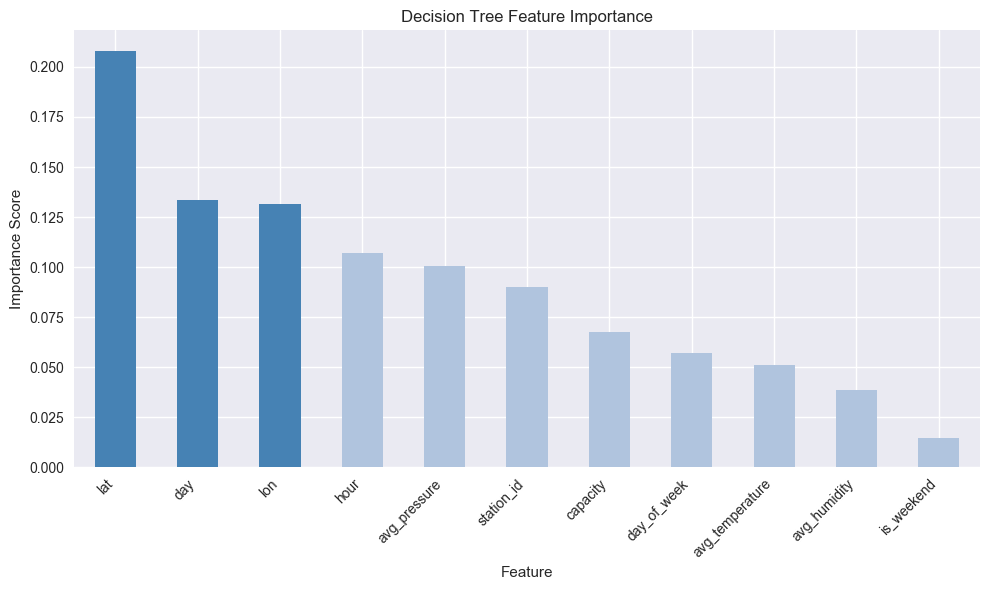

In [14]:
# Get Decision Tree feature importance
best_model = models['Decision Tree']
feature_importance = pd.Series(
    best_model.feature_importances_,
    index=features
).sort_values(ascending=False)

print("📊 Feature importance ranking:")
print(feature_importance)

# Visualization
plt.figure(figsize=(10, 6))
colors = ['steelblue' if i < 3 else 'lightsteelblue' for i in range(len(feature_importance))]
feature_importance.plot(kind='bar', color=colors)
plt.title('Decision Tree Feature Importance')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 9. Save the Best Model

Save the Decision Tree model as a `.pkl` file
for later loading in the Flask app.

Also save the feature list to ensure the same feature order is used during prediction.

In [15]:
# Save Decision Tree model
model_filename = 'bike_availability_model.pkl'

with open(model_filename, 'wb') as f:
    pickle.dump(best_model, f)

# Save the feature list as well
features_filename = 'model_features.pkl'
with open(features_filename, 'wb') as f:
    pickle.dump(features, f)

print(f"✅ Model saved to: {model_filename}")
print(f"✅ Feature list saved to: {features_filename}")

# Validation: reload the model and test
with open(model_filename, 'rb') as f:
    loaded_model = pickle.load(f)

# Validate with the first row of the test set
test_sample = X_test.iloc[[0]]
prediction = loaded_model.predict(test_sample)
actual = y_test.iloc[0]

print(f"\n🔍 Model validation:")
print(f"   Input features: {test_sample.values[0]}")
print(f"   Predicted value: {prediction[0]:.2f} bikes")
print(f"   Actual value: {actual} bikes")
print(f"   Error: {abs(prediction[0] - actual):.2f} bikes")

✅ Model saved to: bike_availability_model.pkl
✅ Feature list saved to: model_features.pkl

🔍 Model validation:
   Input features: [ 97.        40.        53.342113  -6.310015  17.        31.
   1.         0.         9.67      87.4      998.525   ]
   Predicted value: 31.00 bikes
   Actual value: 31 bikes
   Error: 0.00 bikes


## 10. Summary

### Model Training Results

| Model | MAE | RMSE | R² |
|------|-----|------|----|
| Linear Regression | 7.829 | 9.366 | 0.075 |
| **Decision Tree** | **0.970** | **2.376** | **0.941** |
| Random Forest | 2.325 | 3.393 | 0.879 |
| Gradient Boosting | 6.120 | 7.537 | 0.401 |

### Best Model: Decision Tree
- MAE = 0.970 and RMSE = 2.376, giving the lowest prediction errors among all tested models
- R² = 0.941, indicating strong explanatory power on the current test set

### Most Important Features
1. `lat` / `lon` — Geographic location
2. `day` / `hour` — Time
3. `avg_pressure` — Pressure
4. `station_id` / `capacity` — Station information

### Next Steps
- Deploy `bike_availability_model.pkl` to the Flask application
- Use OpenWeather API real-time weather data for prediction